<a href="https://colab.research.google.com/github/Not-kh-lily-23/pulsar-conformal-triage/blob/main/conformal_triage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Loading data from Drive...
Data loaded successfully.
Training LightGBM Baseline...


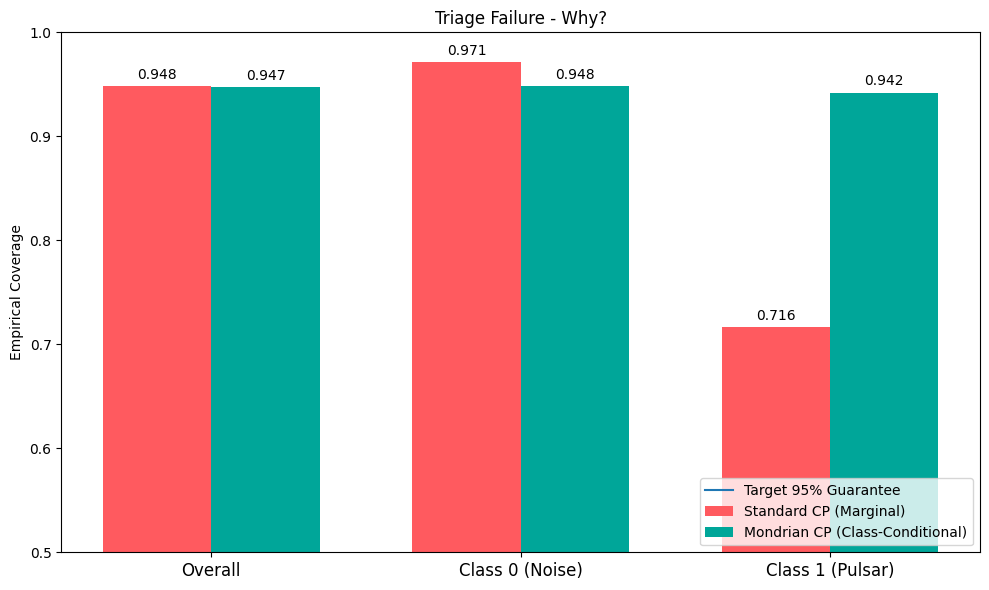


Standard CP Quantile: 0.0653
Mondrian CP Quantiles: Class 0: 0.0281, Class 1: 0.9943


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from google.colab import drive
drive.mount('/content/drive')
processed = '/content/drive/MyDrive/pulsar_project/data/processed'
print("Loading data from Drive...")
try:
    trn_df=pd.read_csv(f"{processed}/train.csv")
    calib_df=pd.read_csv(f"{processed}/calib.csv")
    tst_df=pd.read_csv(f"{processed}/test.csv")
    print("Data loaded successfully.")
except FileNotFoundError:
    raise Exception("Data not found")
x_train,y_train=trn_df.drop(columns=["target"]),trn_df["target"]
x_calib,y_calib=calib_df.drop(columns=["target"]),calib_df["target"]
x_test,y_test=tst_df.drop(columns=["target"]),tst_df["target"]
print("Training LightGBM Baseline...")
clf=lgb.LGBMClassifier(random_state=42,n_estimators=100,verbose=-1)
clf.fit(x_train,y_train)
calib_probs=clf.predict_proba(x_calib)
test_probs=clf.predict_proba(x_test)
calib_scores=1-calib_probs[np.arange(len(y_calib)),y_calib]
test_scores_true_class=1-test_probs[np.arange(len(y_test)),y_test]
alpha=0.05
n=len(y_calib)
q_level=np.ceil((n+1)*(1-alpha))/n
marginal_q=np.quantile(calib_scores,min(1.0,q_level))
marginal_cov_0=np.mean(test_scores_true_class[y_test==0]<=marginal_q)
marginal_cov_1=np.mean(test_scores_true_class[y_test==1]<=marginal_q)
marginal_cov_overall=np.mean(test_scores_true_class<=marginal_q)
scores_0=calib_scores[y_calib==0]
scores_1=calib_scores[y_calib==1]
n_0=len(scores_0)
q_level_0=np.ceil((n_0+1)*(1-alpha))/n_0
q_0=np.quantile(scores_0,min(1.0,q_level_0))
n_1=len(scores_1)
q_level_1=np.ceil((n_1+1)*(1-alpha))/n_1
q_1=np.quantile(scores_1,min(1.0,q_level_1))
mondrian_cov_0=np.mean(test_scores_true_class[y_test==0]<=q_0)
mondrian_cov_1=np.mean(test_scores_true_class[y_test==1]<=q_1)
mondrian_cov_overall=np.mean(test_scores_true_class<=np.where(y_test==0,q_0,q_1))
labels=['Overall','Class 0 (Noise)','Class 1 (Pulsar)']
marginal_bars=[marginal_cov_overall,marginal_cov_0,marginal_cov_1]
mondrian_bars=[mondrian_cov_overall,mondrian_cov_0,mondrian_cov_1]
x=np.arange(len(labels))
width=0.35
fig,ax=plt.subplots(figsize=(10,6))
rects1=ax.bar(x-width/2,marginal_bars,width,label='Standard CP (Marginal)',color='#ff5a5f')
rects2=ax.bar(x+width/2,mondrian_bars,width,label='Mondrian CP (Class-Conditional)',color='#00a699')
ax.axhline(label='Target 95% Guarantee')
ax.set_ylabel('Empirical Coverage')
ax.set_title('Triage Failure - Why?')
ax.set_xticks(x)
ax.set_xticklabels(labels,fontsize=12)
ax.set_ylim(0.5,1.0)
ax.legend(loc='lower right')
for rect in rects1+rects2:
    height=rect.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(rect.get_x()+rect.get_width()/2,height),
                xytext=(0,3),
                textcoords="offset points",
                ha='center',va='bottom',fontsize=10)
plt.tight_layout()
plt.show()
print(f"\nStandard CP Quantile: {marginal_q:.4f}")
print(f"Mondrian CP Quantiles: Class 0: {q_0:.4f}, Class 1: {q_1:.4f}")

In [5]:
import numpy as np
import pandas as pd
def gen_predsets(test_probs,q_0,q_1):
    print(f"Applying mondrian thresholds - class 0 max risk: {q_0:.4f} | class 1 max risk: {q_1:.4f}")
    inc_0=(1-test_probs[:,0])<=q_0
    inc_1=(1-test_probs[:,1])<=q_1
    labels=[]
    for i0, i1 in zip(inc_0,inc_1):
        if i0 and not i1:
            labels.append("Discard (Definitive Noise)")
        elif not i0 and i1:
            labels.append("Telescope (Definitive Pulsar)")
        elif i0 and i1:
            labels.append("Defer (Ambiguous)")
        else:
            labels.append("Anomaly (Empty Set)")
    return np.array(labels)
triage_des=gen_predsets(test_probs,q_0,q_1)
rdf=pd.DataFrame({
    'True_Label':y_test.values,
    'Prob_Pulsar':test_probs[:,1],
    'Triage_Decision':triage_des
})
print("results")
print(rdf['Triage_Decision'].value_counts())
print("safety check")
true_pulsars=rdf[rdf['True_Label']==1]
print(true_pulsars['Triage_Decision'].value_counts())

Applying mondrian thresholds - class 0 max risk: 0.0281 | class 1 max risk: 0.9943
results
Triage_Decision
Discard (Definitive Noise)       2791
Telescope (Definitive Pulsar)     470
Defer (Ambiguous)                 319
Name: count, dtype: int64
safety check
Triage_Decision
Telescope (Definitive Pulsar)    301
Discard (Definitive Noise)        19
Defer (Ambiguous)                  8
Name: count, dtype: int64
